In [25]:
import numpy as np
from glob import glob
import pickle
import matplotlib
import xarray as xr
import matplotlib.pyplot as plt
import math

from scipy.io import readsav
from pandas.core.common import flatten
from scipy import spatial, constants
import pyart
import pandas
import numpy as np
import pandas as pd
import re

In [26]:
def calculate_liquid(profile_in):
    #ALL LIQUID particles 
    length = np.size(profile_in['droplet_count'].values)
    liquid_concentration = (profile_in['droplet_count'].values + profile_in['rain_count'].values)
    
    #mean size of liquid particles
    #before calculating the average size you need to get rid of nans for the size arrays because 5 + nan = nan, not 5d
    topdrop = (profile_in['droplet_count'].values*profile_in['droplet_size'].values)
    ind = np.isnan(topdrop)
    topdrop[ind] = 0.0
    toprain = (profile_in['rain_count'].values*profile_in['rain_size'].values)
    ind = np.isnan(toprain)
    toprain[ind] = 0.0

    top = topdrop + toprain
    liquid_size = (top/liquid_concentration)
    return liquid_size, liquid_concentration

def calculate_frozen(profile_in):
#ALL frozen particles 
    length = np.size(profile_in['ice_count'].values)
    frozen_concentration = (profile_in['ice_count'].values + profile_in['graupel_count'].values + profile_in['hail_count'].values + profile_in['snow_count'].values)
    
    #mean size of frozen/ice particles
    #before calculating the average size you need to get rid of nans for the size arrays because 5 + nan = nan, not 5d
    topice = (profile_in['ice_count'].values*profile_in['ice_size'].values)
    ind = np.isnan(topice)
    topice[ind] = 0.0
    topgraupel = (profile_in['graupel_count'].values*profile_in['graupel_size'].values)
    ind = np.isnan(topgraupel)
    topgraupel[ind] = 0.0
    tophail = (profile_in['hail_count'].values*profile_in['hail_size'].values)
    ind = np.isnan(tophail)
    tophail[ind] = 0.0
    topsnow = (profile_in['snow_count'].values*profile_in['snow_size'].values)
    ind = np.isnan(topsnow)
    topsnow[ind] = 0.0


    top = topice + topgraupel + tophail + topsnow
    frozen_size = (top/frozen_concentration)
    return frozen_size, frozen_concentration

def outside_of_coords(point, coordinates):
    #3d point with format x, y, z
    #Bounding coordinates of the model domain, of the format X+, X-, Y+, Y-, Z+, Z-
    bound = 0
    if point[0] > coordinates[0]:
        bound = 1
    if point[0] < coordinates[1]:
        bound = 1        
    if point[1] > coordinates[2]:
        bound = 1
    if point[1] < coordinates[3]:
        bound = 1
    if point[2] > coordinates[4]:
        bound = 1
    if point[2] < coordinates[5]:
        bound = 1
    return bound

In [31]:
import numpy as np
def knb_mc_sim(m,PROFILE_IN,tree,masktree, LAM_arr,SEEDER = 10,
               LIMIT = 100.,
               HOMOGENEOUS = False,TOL = 0.1,
               coords = [40e3,0.,40e3,0.,20e3,0.], 
               origin = [5e3,5e3,5e3]):
    #Before you start modeling, check that the profile in does or does not have the liquid and frozen
    #size and concentration distributions. If they do, then skip this part. If not, then create the liquid and frozen 
    #size and concentration arrays.
    concentration = PROFILE_IN['particle_concentration'].values
    size = PROFILE_IN['particle_size'].values
    test = str(list(PROFILE_IN.keys()))
    if not re.search('liquid_size',test):
        print('Calculating liquid and frozen microphysics')
        liq_size, liq_count = calculate_liquid(PROFILE_IN)
        frozen_size, frozen_count = calculate_frozen(PROFILE_IN)
    
        liquid_frac = liq_count/concentration
        ind =  np.isnan(liquid_frac)
        liquid_frac[ind] = 0.0 
        
        frozen_frac = frozen_count/concentration
        ind =  np.isnan(frozen_frac)
        frozen_frac[ind] = 0.0 
        
    else: 
        
        liquid_frac = PROFILE_IN['liquid_concentration'].values/concentration
        frozen_frac = PROFILE_IN['frozen_concentration'].values/concentration
    
    length = len(PROFILE_IN['x'])*len(PROFILE_IN['y'])*len(PROFILE_IN['z'])

    liquid_frac = np.reshape(liquid_frac,length)
    frozen_frac= np.reshape(frozen_frac, length)
    ind =  np.isnan(liquid_frac)
    liquid_frac[ind] = 0.0 
    ind =  np.isnan(frozen_frac)
    frozen_frac[ind] = 0.0 
    
    #origin order is [z,y,x] because gridcoords is z,y,x
    print(origin)
    print(coords)
    #coords is xmax,xmin, ymax,ymin, zmax,zmin
    #Find the dx, dy, dz
    dx = PROFILE_IN['x'][1].values - PROFILE_IN['x'][0].values
    dy = PROFILE_IN['y'][1].values - PROFILE_IN['y'][0].values
    dz = PROFILE_IN['z'][1].values - PROFILE_IN['z'][0].values
    
    #make points and kdtree for cloud coordinates
    zz,yy,xx = np.meshgrid(PROFILE_IN['z'].values, PROFILE_IN['y'].values,PROFILE_IN['x'].values,indexing='ij')
    # length = len(PROFILE_IN['x'])*len(PROFILE_IN['y'])*len(PROFILE_IN['z'])
    xx = np.reshape(xx,length)
    yy = np.reshape(yy,length)
    zz = np.reshape(zz,length)
    gridcoords = np.stack((zz,yy,xx),axis = 1) 
    tree = spatial.KDTree(gridcoords)
    
    #Define your boundaries and arrays to hold when a boundary is crossed, specifically if using a hard lateral or vertical boundary
    s = np.size(coords)
    
    ##########CONSTANTS###########
    #Asymmetry factor for a 10micron water drop in the visible spectral region.
    g = 0.87 #double?
    g_ice = 0.88
    g_liq = 0.83
    #single scattering albedo for a water droplet of 10 microns in the visible spectral region.
    w_0 = 0.99998
    w_0liq = 0.9999947
    w_0ice = 0.9999975
    liqp = [ 100.,  95.,  90. , 85. , 80. , 75. , 70.  ,65. , 60. , 55., 50., 45. ,40. ,35. ,30. ,25. ,20., 15.,
     10., 5.]
    icep = [0.,5.,10.,15.,20.,25.,30.,35.,40.,45.,50.,55.,60.,65.,70.,75.,80.,85.,90.,95.]
    #the radius of a typical cloud droplet
    a = 10**-5. #evaluate if e is a double, or long
    N = 10**8.
    LAM = 1./(2.*np.pi*(a**2.)*N)
    # LAM = 70.

    # print(LAM)
    N_dense = np.reshape(concentration,length)
    a_arr = np.reshape(size,length)
    a_arr = np.array([0 if math.isnan(i) else i for i in a_arr])
    N_dense = np.array([0 if math.isnan(i) else i for i in N_dense])
    
    # ######Check microphysical profile
    height = PROFILE_IN['z'].values #reform(profile_in['profile'][:,2])
    if np.nanmax(height) <= 100.:
        height = height*1000.
    #     ######Determine mean free path
    #     #####(m) mean free path of photons with a uniform population of drops.
    #     #LAM_ARR = reform(1./(2.*!dpi*(a_arr^2.)*N_dense))
    LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix
    LAM_arr = np.nan_to_num(LAM_arr,posinf = 999999,neginf = 999999)
    # LAM_arr = np.reshape(LAM_arr,[80,10,10])

    #NOTE, WE USE A MEAN FREE PATH OF 200m here as the cloud boundary. It is on the user to determine if this is appropriate for THEIR CLOUD.
    mask = np.where(LAM_arr <= 200)
    mask = np.array(list(flatten(mask)))
    if len(mask) == 0 :
        print('no clouds here')
        return
    maskstack = np.stack((zz[mask],yy[mask],xx[mask]),axis=1)
    masktree = spatial.KDTree(maskstack)

    
    #####calculate the array of possible scattering angles using the Henyey-Greenstein phase function
    N = 2001#e0
    mu_arr = np.zeros(N)
    mu_arr[0] = -1.#formerly 0D
    for i in np.arange(1,len(mu_arr)-1):
        mu_arr[i] = ((1. + g**2.)-((2.*g)/(N*(1. - g**2.)) + (1. + g**2. - 2.*g*mu_arr[i-1])**(-1./2.))**(-2.))/(2.*g)
        if mu_arr[i] > 1.:
            mu_arr[i] = 1.

    pp = np.arange(len(mu_arr),dtype = int)
    
        #####calculate the array of possible scattering angles using the Henyey-Greenstein phase function
    #HG FOR WATER
    N = 2001#e0
    mu_arr_liq = np.zeros(N)
    mu_arr_liq[0] = -1.#formerly 0D
    g = g_liq
    for i in np.arange(1,len(mu_arr_liq)-1):
        mu_arr_liq[i] = ((1. + g**2.)-((2.*g)/(N*(1. - g**2.)) + (1. + g**2. - 2.*g*mu_arr_liq[i-1])**(-1./2.))**(-2.))/(2.*g)
        if mu_arr_liq[i] > 1.:
            mu_arr_liq[i] = 1.
    
    
    #HG FOR ICE
    N = 2001#e0
    mu_arr_ice = np.zeros(N)
    mu_arr_ice[0] = -1.#formerly 0D
    g = g_ice
    for i in np.arange(1,len(mu_arr_ice)-1):
        mu_arr_ice[i] = ((1. + g**2.)-((2.*g)/(N*(1. - g**2.)) + (1. + g**2. - 2.*g*mu_arr_ice[i-1])**(-1./2.))**(-2.))/(2.*g)
        if mu_arr_ice[i] > 1.:
            mu_arr_ice[i] = 1.
    pp_liq = np.arange(len(mu_arr_liq),dtype = int)#;*********
    pp_ice = np.arange(len(mu_arr_ice),dtype = int)#;*********
    
    
    #*********   
    x_arr = np.zeros(m)
    y_arr = np.zeros(m)
    z_arr = np.zeros(m)
    xprev_arr = np.zeros(m)
    yprev_arr = np.zeros(m)
    zprev_arr = np.zeros(m)
    # zenith_arrout = np.zeros(m)
    # azimuth_arrout = np.zeros(m)
    absorb_flag = np.zeros(m) #0 for scattered through, 1 for if the photon is absorbed
    dist = np.zeros(m) #distance traveled from emission to point of last scattering
    k_arr = np.zeros(m) #number of segments between emission and final position. If 1, no scattering occurred
 
    liq = 0
    ice = 0
 
    # zenith_orig = np.zeros(m)
    # azimuth_orig = np.zeros(m)
    seed1 = SEEDER
    seed2 = seed1 + 1
    seed3 = seed2 + 2
    seed4 = seed3 + 3
    seed5 = seed4 + 4
    seed6 = seed5 + 5
    seed7 = seed6 + 6
    seed8 = seed7 + 7
    seed9 = seed8 + 8

    
    #11/13/2024 Changed phi and theta to azimuth and zenith angles naming convention
    #11/13/2024 Note Phi is the angle from the positive x axis, theta is the angle from the positive z axis. This may be backwards from other conventions
    #changed on on 8/6/2024
    #;initial photon isotropically scattered directions
    rng = np.random.default_rng(seed = seed1)
    u = rng.uniform(0,1,m)#randomu(seed1,m)
    rng = np.random.default_rng(seed = seed2)
    azimuth_0 = rng.uniform(0,2.*math.pi,m)#v = randomu(seed2,m) 

    rng = np.random.default_rng(seed = seed3)
    coszenith = rng.uniform(-1,1,m)
    zenith_0 = np.arccos(coszenith)
    
    rng = np.random.default_rng(seed = seed4)
    ab_arr_m = rng.uniform(0,1, m)
    rng = np.random.default_rng(seed = seed5)
    r_m = rng.uniform(0,1,m) 
    
        

    #UNCOMMENT THIS FOR DISTRIBUTED LAMBDA
    LAM = LAM_arr[tree.query(origin)[1]]
    # LAM = 70.
    # print(LAM)
    x_scat_0 = -LAM*np.log(r_m)
    
    #two cases:
    #1 Emitted in the cloud: 
    #1 emitted out of the cloud
    point = masktree.query(origin)
    if point[0] < LIMIT:
        currentloc = 1
    else: currentloc = 0

    rng = np.random.default_rng(seed = seed6)
    ind_m = rng.uniform(0,1,m) 
    

    rng = np.random.default_rng(seed = seed7)
    zenith_ind_m_seed = rng.uniform(0,1,m) #used to seed something else
    rng = np.random.default_rng(seed = seed8)
    azimuth_r_m = rng.uniform(0,1,m) #used to seed something else
    rng = np.random.default_rng(seed = seed9)
    r_m_1 = rng.uniform(0,1,m)
     

    for j in np.arange(m): 
        if (j % 100) == 0:
            print(j)
        # print(['photon = ' + str(j)])
        counter = 0
        bound = 0
        k=0
        rng = np.random.default_rng(seed = (ab_arr_m[j]*100).astype(int))
        ab_arr = rng.uniform(0,1, 2000000)

        if not np.logical_and(zenith_0[j], azimuth_0[j]):
            print('began the weird case')#  then begin
            mu_x = np.sin(zenith_0[j])*np.cos(azimuth_0[j])
            mu_y = np.sin(zenith_0[j])*np.sin(azimuth_0[j])
            mu_z = np.cos(zenith_0[j])

            #;positions
            x = x + x_scat_0[j]*mu_x
            y = y + x_scat_0[j]*mu_y
            z = z + x_scat_0[j]*mu_z
            endif 

        rng_ind = np.random.default_rng(seed = (ind_m[j]*100.).astype(int))
        ind = rng_ind.uniform(0,1,2000)*1999. + 1.

        #this gives us most angles near 0

        zenith_arr_liq = np.arccos((mu_arr_liq[pp_liq[1:]] + mu_arr_liq[0:-1])/2.)
        zenith_arr_ice = np.arccos((mu_arr_ice[pp_ice[1:]] + mu_arr_ice[0:-1])/2.)

        # # #;*****
        rng = np.random.default_rng(seed = (zenith_ind_m_seed[j]*100.).astype(int))
        zenith_ind = (rng.uniform(0,1,500000)*2000.).astype(int)
        zenith_p_liq = zenith_arr_liq[zenith_ind]
        zenith_p_ice = zenith_arr_ice[zenith_ind]

        rng = np.random.default_rng(seed = (azimuth_r_m[j]*100.).astype(int))
        azimuth_p = rng.uniform(0,2*math.pi,500000)
        rng = np.random.default_rng(seed = (r_m_1[j]*100.).astype(int))
        r = rng.uniform(0,1,500000)
        x_scat = -np.log(r)       

        mu_x = np.sin(zenith_0[j])*np.cos(azimuth_0[j])
        mu_y = np.sin(zenith_0[j])*np.sin(azimuth_0[j])
        mu_z = np.cos(zenith_0[j])

        # ;positions
        xprev = origin[2]
        yprev = origin[1]
        zprev = origin[0]
        x = origin[2] + x_scat_0[j]*mu_x
        y = origin[1] + x_scat_0[j]*mu_y
        z = origin[0] + x_scat_0[j]*mu_z
        previousloc = currentloc
        point = masktree.query([z,y,x])
        if point[0]<LIMIT:
            currentloc = 1
        else:
            currentloc = 0
            
        
 #LOGIC FOR In/Out of cloud options                
        if (previousloc == 0) or (previousloc != currentloc):

            v = [(z - zprev),(y - yprev),(x - xprev)]
            testlam = []
            ptdist = np.sqrt((z-zprev)**2 + (y-yprev)**2 + (x-xprev)**2)

            index = np.arange(500)*(dx/ptdist)
            x1 = xprev + index*v[2]
            y1 = yprev + index*v[1]
            z1 = zprev + index*v[0]
            
            for t in np.arange(500):
                testlam.append((LAM_arr[tree.query([z1[t],y1[t],x1[t]])[1]]))
            newind = np.argmin(np.abs((1+TOL)*LIMIT- np.array(testlam)))   
            if (previousloc == 0) and (currentloc == 0):
                if ~np.any(np.array(testlam) <= (1+TOL)*LIMIT):
                    newind = -1
            min_t = index[newind]
            x = xprev + min_t*v[2]
            y = yprev + min_t*v[1]
            z = zprev + min_t*v[0]
#     #The position has now been updated to the cloud boundary, we can reset and scatter again.
            LAM = testlam[newind]
             

        dist[j] += np.sqrt( (x - xprev)**2 + (y - yprev)**2 + (z - zprev)**2)
        if outside_of_coords([z,y,x], coords):
            # print('ending because bounds')
            x_arr[j] = x
            y_arr[j] = y
            z_arr[j] = z
            xprev_arr[j] = xprev
            yprev_arr[j] = yprev
            zprev_arr[j] = zprev
            k_arr[j]=k
            continue

        # #;******
        while bound < 1: 
            counter +=1
            # ;check to see if absorbed
            if ab_arr[k] > w_0: absorb_flag[j] = 1
            if ab_arr[k] > w_0: break

#Determine if the next interaction is ice or liquid based on height
            liqfrac_here = liquid_frac[tree.query([z,y,x])[1]]
            icefrac_here = frozen_frac[tree.query([z,y,x])[1]]
            if (liqfrac_here == 0.0) and (icefrac_here == 0.0):
                zenith_pk = zenith_p_liq[k]
            if liqfrac_here == 1.0:
                zenith_pk = zenith_p_liq[k]
                liq +=1
            if icefrac_here == 1.0: 
                zenith_pk = zenith_p_ice[k]
                ice += 1
            # print([ab_arr[k],liqfrac_here, icefrac_here])
            if liqfrac_here >0 and liqfrac_here <1.0:
                if (ab_arr[k] >= 0) and (ab_arr[k]<=liqfrac_here):
                    liq +=1 # print('this is liquid')
                    zenith_pk = zenith_p_liq[k]
                if (ab_arr[k] > liqfrac_here) and (ab_arr[k] <= (liqfrac_here + icefrac_here)):
                    ice += 1
                    zenith_pk = zenith_p_ice[k]
                


# ;Find the photon's second position
# ;direction cosines
            denom = np.sqrt(1. - mu_z**2.)
            mu_x_new = ((np.sin(zenith_pk)*(mu_x*mu_z*np.cos(azimuth_p[k]) - mu_y*np.sin(azimuth_p[k])))/denom) + mu_x*np.cos(zenith_pk)
            mu_y_new = ((np.sin(zenith_pk)*(mu_y*mu_z*np.cos(azimuth_p[k]) + mu_x*np.sin(azimuth_p[k])))/denom) + mu_y*np.cos(zenith_pk)
            mu_z_new = -(denom)*np.sin(zenith_pk)*np.cos(azimuth_p[k]) + mu_z*np.cos(zenith_pk)

            #UNCOMMENT THIS FOR DISTRIBUTED LAMBDA
            # print([z,y,x])
            # print(LAM)
            if not math.isfinite(z):
                print('broken')
                break
            if not math.isfinite(y):
                print('broken')
                break
            if not math.isfinite(x):
                print('broken')
                break
            
            LAM = LAM_arr[tree.query([z,y,x])[1]]
            # LAM = 70.

            xprev = x
            yprev = y
            zprev = z
            x = x + LAM*x_scat[k]*mu_x_new
            y = y + LAM*x_scat[k]*mu_y_new
            z = z + LAM*x_scat[k]*mu_z_new
            mu_x = mu_x_new
            mu_y = mu_y_new
            mu_z = mu_z_new
            k += 1
          
  
            previousloc = currentloc
            point = masktree.query([z,y,x])
            if point[0]<LIMIT:
                currentloc = 1
            else:
                currentloc = 0
       
 #LOGIC FOR In/Out of cloud options                
            if (previousloc == 0) or (previousloc != currentloc):

                v = [(z - zprev),(y - yprev),(x - xprev)]
                testlam = []
                ptdist = np.sqrt((z-zprev)**2 + (y-yprev)**2 + (x-xprev)**2)

                index = np.arange(500)*(dx/ptdist)
                x1 = xprev + index*v[2]
                y1 = yprev + index*v[1]
                z1 = zprev + index*v[0]
            
                for t in np.arange(500):
                    testlam.append((LAM_arr[tree.query([z1[t],y1[t],x1[t]])[1]]))
                newind = np.argmin(np.abs((1+TOL)*LIMIT- np.array(testlam)))   
                if (previousloc == 0) and (currentloc == 0):
                    if ~np.any(np.array(testlam) <= (1+TOL)*LIMIT):
                        newind = -1
                min_t = index[newind]
                x = xprev + min_t*v[2]
                y = yprev + min_t*v[1]
                z = zprev + min_t*v[0]
#     #The position has now been updated to the cloud boundary, we can reset and scatter again.
                LAM = testlam[newind]
             

            dist[j] += np.sqrt( (x - xprev)**2 + (y - yprev)**2 + (z - zprev)**2)

            if outside_of_coords([z,y,x], coords):
                bound = 1
            
                
        # dist[j] -= np.sqrt( (x - xprev)**2 + (y - yprev)**2 + (z - zprev)**2)
        x_arr[j] = x
        y_arr[j] = y
        z_arr[j] = z
        xprev_arr[j] = xprev
        yprev_arr[j] = yprev
        zprev_arr[j] = zprev
        k_arr[j]=k
        # print([z,y,x])
    
    # print(absorb)
    array_out =np.column_stack((x_arr,y_arr,z_arr,xprev_arr, yprev_arr, zprev_arr,k_arr,absorb_flag,dist)) #,zenith_arrout,azimuth_arrout))
    return(array_out)#, pathx,pathy,pathz)  


In [32]:
origin = [4062.5,21e3,15e3]
# origin = [5e3,22e3,17e3]
# origin = [5e3,19.5e3,14.5e3]
# origin = [8437.5,19.5e3,14.5e3]
# origin = [4062.5,9000.0,9250.0]

m = 500

profile_in =xr.open_dataset('/Users/kelcy/PYTHON/KNB_PYMC/github/3D_COMMAS_KTAL071015B_30s.002430.nc')
zs = profile_in['z'].values
xs = profile_in['x'].values
ys = profile_in['y'].values
        #make points and kdtree for cloud coordinates
zz,yy,xx = np.meshgrid(profile_in['z'].values, profile_in['y'].values,profile_in['x'].values,indexing='ij')
length = len(profile_in['x'])*len(profile_in['y'])*len(profile_in['z'])
xx = np.reshape(xx,length)
yy = np.reshape(yy,length)
zz = np.reshape(zz,length)
gridcoords = np.stack((zz,yy,xx),axis = 1) 
tree = spatial.KDTree(gridcoords)
    
N_dense = np.reshape(profile_in['particle_concentration'].values,length)
a_arr = np.reshape(profile_in['particle_size'].values,length)
a_arr = np.array([0 if math.isnan(i) else i for i in a_arr])
N_dense = np.array([0 if math.isnan(i) else i for i in N_dense])
    
    # ######Check microphysical profile

LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix
LAM_arr = np.nan_to_num(LAM_arr,posinf = 999999,neginf = 999999)
    # LAM_arr = np.reshape(LAM_arr,[80,10,10])

    #NOTE, WE USE A MEAN FREE PATH OF 200m here as the cloud boundary. It is on the user to determine if this is appropriate for THEIR CLOUD.
mask = np.where(LAM_arr <= 200)
mask = np.array(list(flatten(mask)))
maskstack = np.stack((zz[mask],yy[mask],xx[mask]),axis=1)
masktree = spatial.KDTree(maskstack)

    

out = knb_mc_sim(m,profile_in,tree,masktree,LAM_arr,SEEDER  = 10,origin = origin, LIMIT = 500.)

# df = pd.DataFrame(out)
# file_name = 'COMMAS30s_'+str(origin[0])[:-2]+'_'+str(origin[1])[:-2]+'_'+str(origin[2])[:-2]+'_homogeneous.csv'
# print(file_name)
# df.to_csv(file_name, index=False)



/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_36210/1339642981.py:32: RuntimeWarning: divide by zero encountered in true_divide
  LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix


Calculating liquid and frozen microphysics


/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_36210/3344206134.py:16: RuntimeWarning: invalid value encountered in true_divide
  liquid_size = (top/liquid_concentration)
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_36210/3344206134.py:41: RuntimeWarning: invalid value encountered in true_divide
  frozen_size = (top/frozen_concentration)
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_36210/2885267892.py:18: RuntimeWarning: invalid value encountered in true_divide
  liquid_frac = liq_count/concentration
/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_36210/2885267892.py:22: RuntimeWarning: invalid value encountered in true_divide
  frozen_frac = frozen_count/concentration


[4062.5, 21000.0, 15000.0]
[40000.0, 0.0, 40000.0, 0.0, 20000.0, 0.0]


/var/folders/v0/w2wv99k55flflfdxrrl4r5q80000gn/T/ipykernel_36210/2885267892.py:92: RuntimeWarning: divide by zero encountered in true_divide
  LAM_arr = (1./(2.*math.pi*(a_arr**2.)*N_dense)) #make sure a_arr isn't creating a matrix


0
100
200
300
400


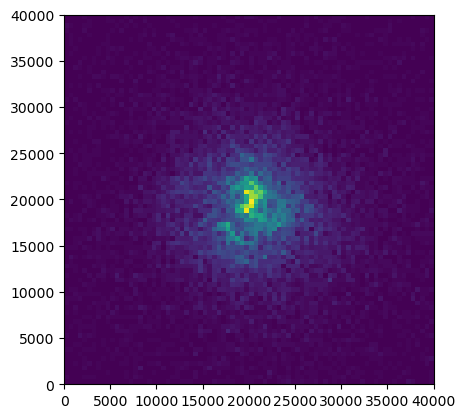

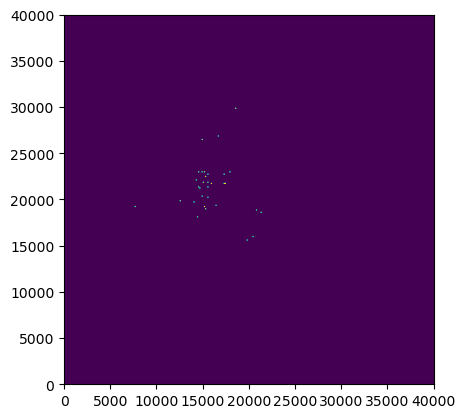

In [169]:
#creates 2 heatmaps, one of absorption and one of emission (exiting the cloud)



#EMITTED
outgrid = np.zeros([len(data['XC'])])
# grid_z2 = griddata(out[zp,0]/1e3,out[zp,1]/1e3, values, (grid_x, grid_y), method='cubic')
import numpy as np
import numpy.random
import matplotlib.pyplot as plt
# zp = list(flatten(np.where((dist > 1100.))))
zp = list(flatten((dist > 1100.)))

# Generate some test data
x = out[zp,0]
y = out[zp,1]

# heatmap, xedges, yedges = np.histogram2d(y, x, range=[[0, np.nanmax(data['XE'])], [0, np.nanmax(data['YE'])]],bins = [len(data['XC']),len(data['YC'])],density = True)
heatmap, xedges, yedges = np.histogram2d(y, x, range=[[0, np.nanmax(data['XE'])], [0, np.nanmax(data['YE'])]],bins = [80,80],density = False)

extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
# extent = [0, np.nanmax(data['XE']),0, np.nanmax(data['XE'])]

plt.clf()
plt.imshow(heatmap, extent=extent, origin='lower')
plt.show()

#ABSORBED
outgrid = np.zeros([len(data['XC']),len(data['XC'])])
zp = list(flatten((dist <= 1100.)))

# Generate some test data
x = out[zp,0]
y = out[zp,1]

heatmap5, xedges5, yedges5 = np.histogram2d(y, x, range=[[0, np.nanmax(data['XE'])], [0, np.nanmax(data['YE'])]],bins = [len(data['XC']),len(data['YC'])],density = True)
# extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
extent = [0, np.nanmax(data['XE']),0, np.nanmax(data['XE'])]

plt.clf()
plt.imshow(heatmap5, extent=extent, origin='lower')
plt.show()

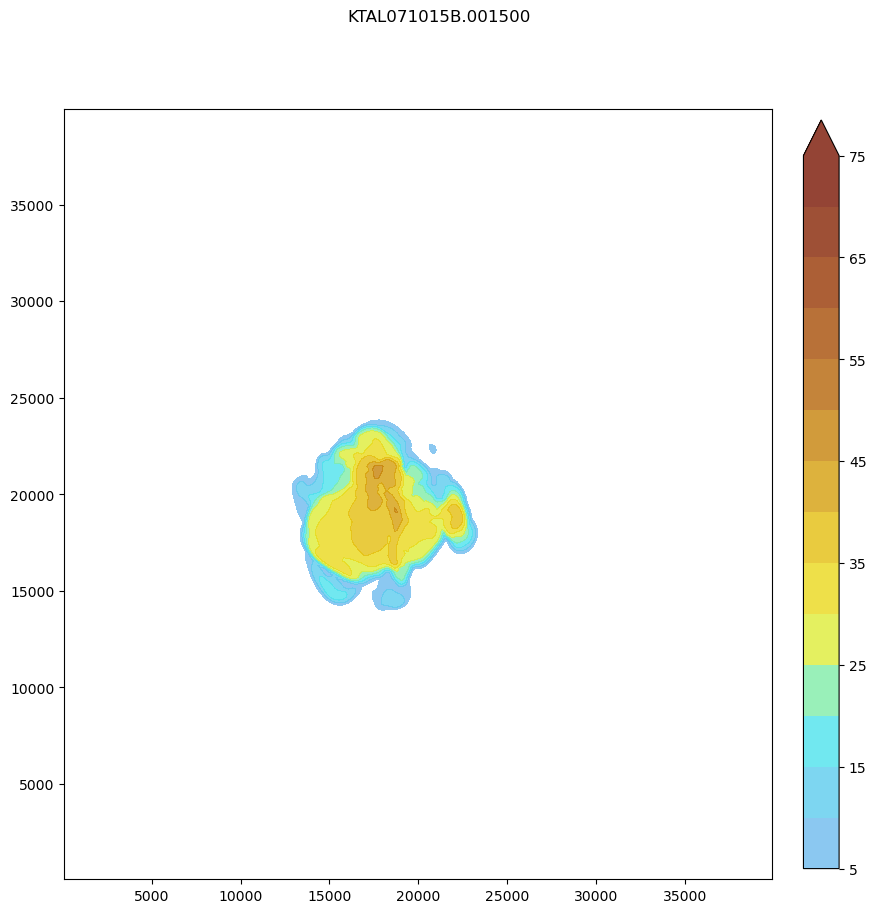

In [175]:
# out #= out5
# maxrefl = data['REFL_10CM'].max(axis=1)
frame = 0

ref_levels = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75]
photon_levels = [1,2,5,10,25,40,65,80,90,125,150,200,350,500]
# photon_levels = [0.005,0.01,0.025,0.05,0.075,0.1,0.25,0.5,0.75,1,1.5,2,2.5,3,3.5,4,4.5,5]
# photon_levels = [0.1,0.25,0.5,0.75,1,1.5,2,2.5,3,3.5,4,4.5,5,6,7,8,9,10]

lambda_levels = [1,2,3,5,10,15,25,50,75,100,150,200,350,500,600,800,1000]
lambda_levels = [1,2,3,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,125,150,175,200]#25,50,75,100]#,350,500,600,800,1000]

fig, ax = plt.subplots(figsize=(10,10))

refl = maxrefl#maxrefl[frame,:,:]
fig.suptitle(str(end))
y_mesh, x_mesh = np.meshgrid(data['YC'],data['XC'])
ymesh2,xmesh2=np.meshgrid(xedges[0:80],yedges[0:80])
    
refplt = ax.contourf(y_mesh,x_mesh, refl, extend = 'max',levels = ref_levels,cmap='pyart_LangRainbow12',origin = 'lower', vmin=-24, vmax=72, alpha = 0.8)#,extent = [0,-10000,-20000,-10000])

fig.colorbar(refplt,fraction=0.046, pad=0.04)

# refplt2 = ax.contourf(ymesh2, xmesh2, heatmap5, extend = 'max',cmap='Greys_r',levels = photon_levels,origin = 'lower',vmin=1)#,extent = [0,-10000,-20000,-10000])
# refplt2 = ax.contourf(y_mesh, x_mesh, data['QC'].max(axis=1)[0,:,:]*1000, extend = 'max',cmap='Greys_r',alpha = 1.0,origin = 'lower',levels = lambda_levels)#,extent = [0,-10000,-20000,-10000])
# refplt3 = ax.contourf(ymesh2, xmesh2, heatmap, extend = 'max',cmap='gist_heat_r',levels = photon_levels,alpha=0.9,origin = 'lower',vmin=1)#,extent = [0,-10000,-20000,-10000])
# refplt2 = ax.contourf(y_mesh, x_mesh, LAMreshape, extend = 'max',cmap='Greys_r',alpha = 1.0,origin = 'lower',levels = lambda_levels)#,extent = [0,-10000,-20000,-10000])


# test = (np.reshape(LAM_arr,[160,320,320]))
# LAMreshape = test[32,:,:]
# mask = np.where(LAMreshape < 200)
# pt2 = ax.scatter(data['YC'][mask[1]],data['XC'][mask[0]],marker = '*', color = 'black')

# mask = np.where(LAMreshape < 15)
# # pt2 = ax.scatter(data['YC'][mask[1]],data['XC'][mask[0]],marker = '*', color = 'blue')
# fig.colorbar(refplt2,fraction=0.046, pad=0.04)
# fig.colorbar(refplt3,fraction=0.05, pad=0.04)


# pt2 = ax.scatter(20e3,20e3,marker = 'o' ,color = 'red',s = 25.0)

# ax.scatter(out[:,0], out[:,1], out[:,2])
# ax.set_xlim(0, 140)
# ax.set_ylim(0, 140)
# ax.set_zlim(18e3, 0.)
# plt.show()
# fig.suptitle('Light escaping the cloud (percentage)', fontsize=16,y=0.92)
# savedir = "/Users/kelcy/Documents/ABSTRACT:CONFERENCE/GLM_SCIENCE_2024/"
# fig.savefig(savedir+'Light_emitted_percentage_v2.pdf',format = 'pdf',dpi=1200)



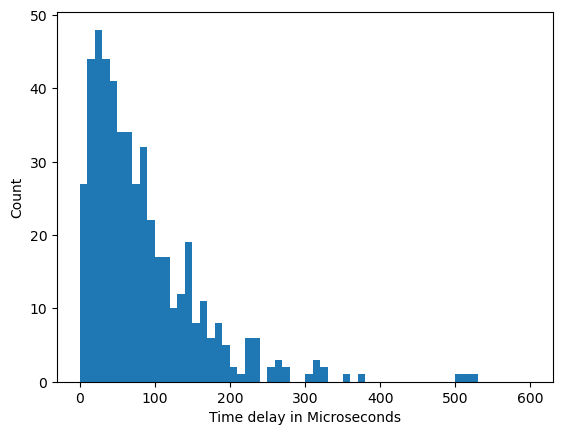

In [14]:
#Evaluate the time delay the photons experienced between emission and exiting the cloud or absorption
tdelay = out[:,-1]/constants.c
# tdelay*(10**(6))
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(1)#, sharey=True, tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axs.hist(tdelay*(10**(6)),bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,
                                  210,220,230,240,250,260,270,280,290,300,310,320,330,340,350,360,370,380,390,400,
                                  410,420,430,440,450,460,470,480,490,500,510,520,530,540,550,560,570,580,590,600])
# axs[1].hist(dist2, bins=n_bins)
axs.set_xlabel('Time delay in Microseconds')
axs.set_ylabel('Count')

plt.show()

